In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/cleaned_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(
    ["Product_ID", "Date"]
).reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (15000, 16)


,Date,Product_ID,Category,Price,Discount,On_Promotion,Weekend,Month,DayOfWeek,Current_Stock,Sales_Quantity,Revenue,Supplier_Lead_Time,Stockout_Risk,Yesterday_Sales,Avg_Sales_7Days
0,2025-01-01,SKU_0001,Beauty,57.54,0,0,0,1,2,122,101,5811.54,3,0,0,101.00
1,2025-01-02,SKU_0001,Beauty,57.54,15,1,0,1,3,163,149,7287.44,3,1,101,125.00
2,2025-01-03,SKU_0001,Beauty,57.54,0,0,0,1,4,94,102,5869.08,3,1,149,117.33
3,2025-01-04,SKU_0001,Beauty,57.54,0,0,1,1,5,178,139,7998.06,3,0,102,122.75
4,2025-01-05,SKU_0001,Beauty,57.54,0,0,1,1,6,149,137,7882.98,3,1,139,125.60


In [3]:
# Check whether Yesterday_Sales matches the previous day's sales

df["Actual_Previous_Day_Sales"] = (
    df.groupby("Product_ID")["Sales_Quantity"]
      .shift(1)
)

comparison = df.dropna(
    subset=["Actual_Previous_Day_Sales"]
)

matches = (
    comparison["Yesterday_Sales"] ==
    comparison["Actual_Previous_Day_Sales"]
).sum()

total = len(comparison)

print("===== YESTERDAY SALES CHECK =====")
print("Rows checked:", total)
print("Matching rows:", matches)
print("Match percentage:", round(matches / total * 100, 2), "%")

===== YESTERDAY SALES CHECK =====
Rows checked: 14900
Matching rows: 14900
Match percentage: 100.0 %


In [4]:
# Calculate previous 7-day average sales independently

df["Calculated_Avg_Sales_7Days"] = (
    df.groupby("Product_ID")["Sales_Quantity"]
      .transform(
          lambda x: x.shift(1).rolling(7, min_periods=1).mean()
      )
)

comparison_7 = df.dropna(
    subset=["Calculated_Avg_Sales_7Days"]
)

difference = (
    comparison_7["Avg_Sales_7Days"] -
    comparison_7["Calculated_Avg_Sales_7Days"]
).abs()

print("===== 7-DAY AVERAGE CHECK =====")
print("Maximum difference:", difference.max())
print("Mean difference:", difference.mean())
print(
    "Rows within 0.01:",
    (difference <= 0.01).sum(),
    "out of",
    len(difference)
)

===== 7-DAY AVERAGE CHECK =====
Maximum difference: 32.0
Mean difference: 2.184051454138703
Rows within 0.01: 936 out of 14900


In [5]:
# Create weekly SKU-level demand

weekly_df = (
    df.groupby(
        [
            "Product_ID",
            "Category",
            pd.Grouper(key="Date", freq="W")
        ]
    )
    .agg(
        Weekly_Demand=("Sales_Quantity", "sum"),
        Avg_Price=("Price", "mean"),
        Avg_Discount=("Discount", "mean"),
        Promotion_Days=("On_Promotion", "sum"),
        Avg_Stock=("Current_Stock", "mean"),
        Avg_Lead_Time=("Supplier_Lead_Time", "mean")
    )
    .reset_index()
)

print("===== WEEKLY DATASET =====")
print("Shape:", weekly_df.shape)

weekly_df.head(10)

===== WEEKLY DATASET =====
Shape: (2200, 9)


,Product_ID,Category,Date,Weekly_Demand,Avg_Price,Avg_Discount,Promotion_Days,Avg_Stock,Avg_Lead_Time
0,SKU_0001,Beauty,2025-01-05,628,57.54,3.000000,1,141.200000,3.0
1,SKU_0001,Beauty,2025-01-12,896,57.54,2.142857,2,148.000000,3.0
2,SKU_0001,Beauty,2025-01-19,785,57.54,0.000000,0,123.857143,3.0
3,SKU_0001,Beauty,2025-01-26,822,57.54,2.857143,1,134.428571,3.0
4,SKU_0001,Beauty,2025-02-02,832,57.54,3.571429,1,138.857143,3.0
5,SKU_0001,Beauty,2025-02-09,836,57.54,2.857143,1,125.428571,3.0
6,SKU_0001,Beauty,2025-02-16,828,57.54,2.142857,1,138.571429,3.0
7,SKU_0001,Beauty,2025-02-23,784,57.54,0.000000,0,136.571429,3.0
8,SKU_0001,Beauty,2025-03-02,818,57.54,3.571429,1,135.142857,3.0
9,SKU_0001,Beauty,2025-03-09,933,57.54,5.714286,3,143.857143,3.0


In [6]:
# Sort weekly data chronologically for each SKU

weekly_df = weekly_df.sort_values(
    ["Product_ID", "Date"]
).reset_index(drop=True)

print(weekly_df.head(10))

  Product_ID Category       Date  Weekly_Demand  Avg_Price  Avg_Discount  \
0   SKU_0001   Beauty 2025-01-05            628      57.54      3.000000   
1   SKU_0001   Beauty 2025-01-12            896      57.54      2.142857   
2   SKU_0001   Beauty 2025-01-19            785      57.54      0.000000   
3   SKU_0001   Beauty 2025-01-26            822      57.54      2.857143   
4   SKU_0001   Beauty 2025-02-02            832      57.54      3.571429   
5   SKU_0001   Beauty 2025-02-09            836      57.54      2.857143   
6   SKU_0001   Beauty 2025-02-16            828      57.54      2.142857   
7   SKU_0001   Beauty 2025-02-23            784      57.54      0.000000   
8   SKU_0001   Beauty 2025-03-02            818      57.54      3.571429   
9   SKU_0001   Beauty 2025-03-09            933      57.54      5.714286   

   Promotion_Days   Avg_Stock  Avg_Lead_Time  
0               1  141.200000            3.0  
1               2  148.000000            3.0  
2               0  123

In [7]:
# Create historical demand lags

weekly_df["Lag_1"] = (
    weekly_df.groupby("Product_ID")["Weekly_Demand"]
             .shift(1)
)

weekly_df["Lag_2"] = (
    weekly_df.groupby("Product_ID")["Weekly_Demand"]
             .shift(2)
)

weekly_df["Lag_4"] = (
    weekly_df.groupby("Product_ID")["Weekly_Demand"]
             .shift(4)
)

print(weekly_df.head(10))

  Product_ID Category       Date  Weekly_Demand  Avg_Price  Avg_Discount  \
0   SKU_0001   Beauty 2025-01-05            628      57.54      3.000000   
1   SKU_0001   Beauty 2025-01-12            896      57.54      2.142857   
2   SKU_0001   Beauty 2025-01-19            785      57.54      0.000000   
3   SKU_0001   Beauty 2025-01-26            822      57.54      2.857143   
4   SKU_0001   Beauty 2025-02-02            832      57.54      3.571429   
5   SKU_0001   Beauty 2025-02-09            836      57.54      2.857143   
6   SKU_0001   Beauty 2025-02-16            828      57.54      2.142857   
7   SKU_0001   Beauty 2025-02-23            784      57.54      0.000000   
8   SKU_0001   Beauty 2025-03-02            818      57.54      3.571429   
9   SKU_0001   Beauty 2025-03-09            933      57.54      5.714286   

   Promotion_Days   Avg_Stock  Avg_Lead_Time  Lag_1  Lag_2  Lag_4  
0               1  141.200000            3.0    NaN    NaN    NaN  
1               2  148.0000

In [8]:
# Create historical rolling demand features

weekly_df["Rolling_Mean_4"] = (
    weekly_df.groupby("Product_ID")["Weekly_Demand"]
             .transform(
                 lambda x: x.shift(1).rolling(4, min_periods=2).mean()
             )
)

weekly_df["Rolling_Mean_8"] = (
    weekly_df.groupby("Product_ID")["Weekly_Demand"]
             .transform(
                 lambda x: x.shift(1).rolling(8, min_periods=4).mean()
             )
)

print("===== ROLLING FEATURES =====")
print(
    weekly_df[
        [
            "Product_ID",
            "Date",
            "Weekly_Demand",
            "Lag_1",
            "Lag_2",
            "Lag_4",
            "Rolling_Mean_4",
            "Rolling_Mean_8"
        ]
    ].head(12)
)

===== ROLLING FEATURES =====
   Product_ID       Date  Weekly_Demand   Lag_1  Lag_2  Lag_4  Rolling_Mean_4  \
0    SKU_0001 2025-01-05            628     NaN    NaN    NaN             NaN   
1    SKU_0001 2025-01-12            896   628.0    NaN    NaN             NaN   
2    SKU_0001 2025-01-19            785   896.0  628.0    NaN      762.000000   
3    SKU_0001 2025-01-26            822   785.0  896.0    NaN      769.666667   
4    SKU_0001 2025-02-02            832   822.0  785.0  628.0      782.750000   
5    SKU_0001 2025-02-09            836   832.0  822.0  896.0      833.750000   
6    SKU_0001 2025-02-16            828   836.0  832.0  785.0      818.750000   
7    SKU_0001 2025-02-23            784   828.0  836.0  822.0      829.500000   
8    SKU_0001 2025-03-02            818   784.0  828.0  832.0      820.000000   
9    SKU_0001 2025-03-09            933   818.0  784.0  836.0      816.500000   
10   SKU_0001 2025-03-16           1001   933.0  818.0  828.0      840.750000   

In [9]:
# Check missing values created by lag and rolling features

print("===== MISSING VALUES =====")

print(
    weekly_df[
        [
            "Lag_1",
            "Lag_2",
            "Lag_4",
            "Rolling_Mean_4",
            "Rolling_Mean_8"
        ]
    ].isnull().sum()
)

===== MISSING VALUES =====
Lag_1             100
Lag_2             200
Lag_4             400
Rolling_Mean_4    200
Rolling_Mean_8    400
dtype: int64


In [10]:
# Create calendar and promotion features

weekly_df["WeekOfYear"] = weekly_df["Date"].dt.isocalendar().week.astype(int)
weekly_df["Month"] = weekly_df["Date"].dt.month
weekly_df["Quarter"] = weekly_df["Date"].dt.quarter

print("===== CALENDAR FEATURES =====")

print(
    weekly_df[
        [
            "Product_ID",
            "Date",
            "Weekly_Demand",
            "WeekOfYear",
            "Month",
            "Quarter",
            "Avg_Discount",
            "Promotion_Days"
        ]
    ].head(10)
)

===== CALENDAR FEATURES =====
  Product_ID       Date  Weekly_Demand  WeekOfYear  Month  Quarter  \
0   SKU_0001 2025-01-05            628           1      1        1   
1   SKU_0001 2025-01-12            896           2      1        1   
2   SKU_0001 2025-01-19            785           3      1        1   
3   SKU_0001 2025-01-26            822           4      1        1   
4   SKU_0001 2025-02-02            832           5      2        1   
5   SKU_0001 2025-02-09            836           6      2        1   
6   SKU_0001 2025-02-16            828           7      2        1   
7   SKU_0001 2025-02-23            784           8      2        1   
8   SKU_0001 2025-03-02            818           9      3        1   
9   SKU_0001 2025-03-09            933          10      3        1   

   Avg_Discount  Promotion_Days  
0      3.000000               1  
1      2.142857               2  
2      0.000000               0  
3      2.857143               1  
4      3.571429              

In [11]:
# Display all forecasting features

print("===== FORECASTING DATASET COLUMNS =====")

print(weekly_df.columns.tolist())

print("\nShape:", weekly_df.shape)

===== FORECASTING DATASET COLUMNS =====
['Product_ID', 'Category', 'Date', 'Weekly_Demand', 'Avg_Price', 'Avg_Discount', 'Promotion_Days', 'Avg_Stock', 'Avg_Lead_Time', 'Lag_1', 'Lag_2', 'Lag_4', 'Rolling_Mean_4', 'Rolling_Mean_8', 'WeekOfYear', 'Month', 'Quarter']

Shape: (2200, 17)


In [12]:
# Remove rows without enough historical demand information

forecast_df = weekly_df.dropna(
    subset=[
        "Lag_1",
        "Lag_2",
        "Lag_4",
        "Rolling_Mean_4",
        "Rolling_Mean_8"
    ]
).copy()

print("===== FORECASTING DATASET AFTER CLEANING =====")
print("Original rows:", len(weekly_df))
print("Rows after removing insufficient history:", len(forecast_df))
print("Rows removed:", len(weekly_df) - len(forecast_df))

print("\nMissing values:")
print(
    forecast_df[
        [
            "Lag_1",
            "Lag_2",
            "Lag_4",
            "Rolling_Mean_4",
            "Rolling_Mean_8"
        ]
    ].isnull().sum()
)

===== FORECASTING DATASET AFTER CLEANING =====
Original rows: 2200
Rows after removing insufficient history: 1800
Rows removed: 400

Missing values:
Lag_1             0
Lag_2             0
Lag_4             0
Rolling_Mean_4    0
Rolling_Mean_8    0
dtype: int64


In [13]:
print("===== FINAL FORECASTING DATA =====")

print("Shape:", forecast_df.shape)

print("\nColumns:")
print(forecast_df.columns.tolist())

print("\nSample:")
print(forecast_df.head())

===== FINAL FORECASTING DATA =====
Shape: (1800, 17)

Columns:
['Product_ID', 'Category', 'Date', 'Weekly_Demand', 'Avg_Price', 'Avg_Discount', 'Promotion_Days', 'Avg_Stock', 'Avg_Lead_Time', 'Lag_1', 'Lag_2', 'Lag_4', 'Rolling_Mean_4', 'Rolling_Mean_8', 'WeekOfYear', 'Month', 'Quarter']

Sample:
  Product_ID Category       Date  Weekly_Demand  Avg_Price  Avg_Discount  \
4   SKU_0001   Beauty 2025-02-02            832      57.54      3.571429   
5   SKU_0001   Beauty 2025-02-09            836      57.54      2.857143   
6   SKU_0001   Beauty 2025-02-16            828      57.54      2.142857   
7   SKU_0001   Beauty 2025-02-23            784      57.54      0.000000   
8   SKU_0001   Beauty 2025-03-02            818      57.54      3.571429   

   Promotion_Days   Avg_Stock  Avg_Lead_Time  Lag_1  Lag_2  Lag_4  \
4               1  138.857143            3.0  822.0  785.0  628.0   
5               1  125.428571            3.0  832.0  822.0  896.0   
6               1  138.571429         

In [14]:
# Define target and forecasting features

features = [
    "Avg_Price",
    "Avg_Discount",
    "Promotion_Days",
    "Avg_Stock",
    "Avg_Lead_Time",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "WeekOfYear",
    "Month",
    "Quarter"
]

X = forecast_df[features].copy()
y = forecast_df["Weekly_Demand"].copy()

print("===== MODEL DATA =====")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(features)

print("\nTarget:")
print("Weekly_Demand")

===== MODEL DATA =====
X shape: (1800, 13)
y shape: (1800,)

Features:
['Avg_Price', 'Avg_Discount', 'Promotion_Days', 'Avg_Stock', 'Avg_Lead_Time', 'Lag_1', 'Lag_2', 'Lag_4', 'Rolling_Mean_4', 'Rolling_Mean_8', 'WeekOfYear', 'Month', 'Quarter']

Target:
Weekly_Demand


In [15]:
# Time-based train/test split

split_date = forecast_df["Date"].quantile(0.80)

train_df = forecast_df[
    forecast_df["Date"] <= split_date
].copy()

test_df = forecast_df[
    forecast_df["Date"] > split_date
].copy()

print("===== TIME-BASED SPLIT =====")
print("Split date:", split_date)

print("\nTraining data:")
print("Rows:", len(train_df))
print("Start:", train_df["Date"].min())
print("End:", train_df["Date"].max())

print("\nTest data:")
print("Rows:", len(test_df))
print("Start:", test_df["Date"].min())
print("End:", test_df["Date"].max())

===== TIME-BASED SPLIT =====
Split date: 2025-05-11 00:00:00

Training data:
Rows: 1500
Start: 2025-02-02 00:00:00
End: 2025-05-11 00:00:00

Test data:
Rows: 300
Start: 2025-05-18 00:00:00
End: 2025-06-01 00:00:00


In [16]:
# Prepare training and testing data

X_train = train_df[features].copy()
y_train = train_df["Weekly_Demand"].copy()

X_test = test_df[features].copy()
y_test = test_df["Weekly_Demand"].copy()

print("===== TRAIN / TEST DATA =====")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

===== TRAIN / TEST DATA =====
X_train: (1500, 13)
y_train: (1500,)
X_test: (300, 13)
y_test: (300,)


In [17]:
from sklearn.ensemble import RandomForestRegressor

# Create forecasting model

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [18]:
# Predict weekly demand on the test period

y_pred = model.predict(X_test)

print("===== SAMPLE PREDICTIONS =====")

results = pd.DataFrame({
    "Actual_Demand": y_test.values,
    "Predicted_Demand": y_pred
})

print(results.head(10))

===== SAMPLE PREDICTIONS =====
   Actual_Demand  Predicted_Demand
0            774        782.136102
1            794        785.498826
2            509        778.908835
3            781        780.859495
4            732        735.523966
5            517        761.199463
6            893        899.765070
7            945        977.801856
8            556        825.874349
9            786        775.409083


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Avoid division by zero for MAPE
mape = np.mean(
    np.abs(
        (y_test.values - y_pred) /
        np.where(y_test.values == 0, 1, y_test.values)
    )
) * 100

print("===== MODEL EVALUATION =====")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

===== MODEL EVALUATION =====
MAE : 88.05
RMSE: 145.03
MAPE: 17.37 %


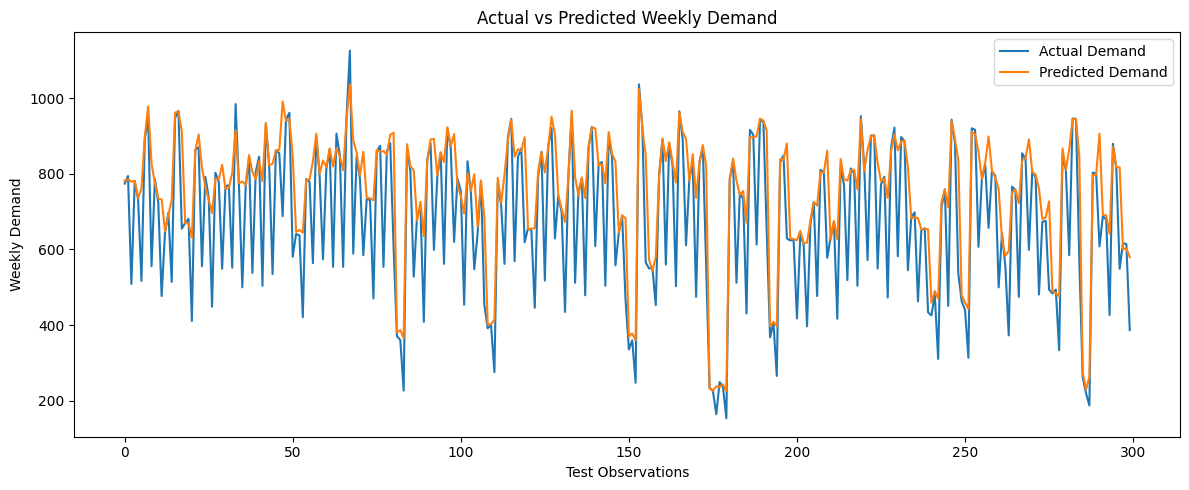

In [21]:
# Actual vs Predicted Demand

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values,
    label="Actual Demand"
)

plt.plot(
    y_pred,
    label="Predicted Demand"
)

plt.title("Actual vs Predicted Weekly Demand")
plt.xlabel("Test Observations")
plt.ylabel("Weekly Demand")
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# Feature importance analysis

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("===== FEATURE IMPORTANCE =====")
print(importance)

===== FEATURE IMPORTANCE =====
           Feature  Importance
0        Avg_Price    0.532060
3        Avg_Stock    0.231150
9   Rolling_Mean_8    0.121736
8   Rolling_Mean_4    0.065247
6            Lag_2    0.018528
2   Promotion_Days    0.014141
5            Lag_1    0.009378
1     Avg_Discount    0.005699
7            Lag_4    0.001119
4    Avg_Lead_Time    0.000433
10      WeekOfYear    0.000349
11           Month    0.000117
12         Quarter    0.000043


<Figure size 1000x600 with 0 Axes>

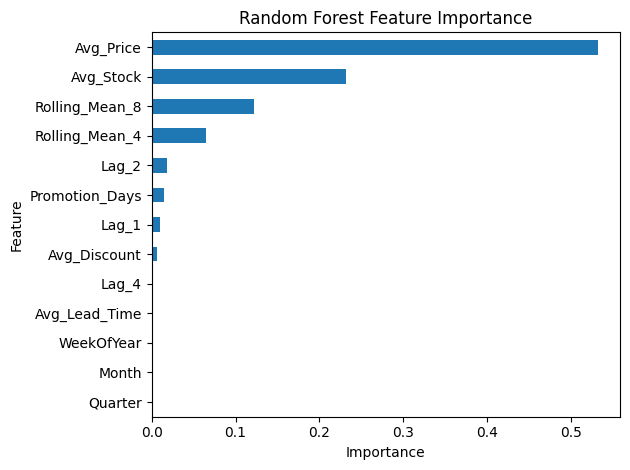

In [23]:
# Visualize feature importance

plt.figure(figsize=(10, 6))

importance.sort_values(
    "Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [24]:
# Store actual and predicted demand together

prediction_results = test_df[
    ["Product_ID", "Category", "Date",
     "Weekly_Demand", "Avg_Stock", "Avg_Lead_Time"]
].copy()

prediction_results["Predicted_Demand"] = y_pred

print("===== PREDICTION RESULTS =====")
print(prediction_results.head(10))

print("\nShape:", prediction_results.shape)

===== PREDICTION RESULTS =====
   Product_ID        Category       Date  Weekly_Demand   Avg_Stock  \
19   SKU_0001          Beauty 2025-05-18            774  122.571429   
20   SKU_0001          Beauty 2025-05-25            794  134.000000   
21   SKU_0001          Beauty 2025-06-01            509  114.600000   
41   SKU_0002          Sports 2025-05-18            781  129.142857   
42   SKU_0002          Sports 2025-05-25            732  121.714286   
43   SKU_0002          Sports 2025-06-01            517  115.000000   
63   SKU_0003  Home & Kitchen 2025-05-18            893  140.857143   
64   SKU_0003  Home & Kitchen 2025-05-25            945  161.571429   
65   SKU_0003  Home & Kitchen 2025-06-01            556  115.400000   
85   SKU_0004          Sports 2025-05-18            786  123.142857   

    Avg_Lead_Time  Predicted_Demand  
19            3.0        782.136102  
20            3.0        785.498826  
21            3.0        778.908835  
41            2.0        780.859495

In [25]:
# Calculate expected demand during supplier lead time

prediction_results["Lead_Time_Demand"] = (
    prediction_results["Predicted_Demand"]
    * prediction_results["Avg_Lead_Time"]
    / 7
)

print("===== LEAD TIME DEMAND =====")

print(
    prediction_results[
        [
            "Product_ID",
            "Date",
            "Predicted_Demand",
            "Avg_Lead_Time",
            "Lead_Time_Demand",
            "Avg_Stock"
        ]
    ].head(10)
)

===== LEAD TIME DEMAND =====
   Product_ID       Date  Predicted_Demand  Avg_Lead_Time  Lead_Time_Demand  \
19   SKU_0001 2025-05-18        782.136102            3.0        335.201187   
20   SKU_0001 2025-05-25        785.498826            3.0        336.642354   
21   SKU_0001 2025-06-01        778.908835            3.0        333.818072   
41   SKU_0002 2025-05-18        780.859495            2.0        223.102713   
42   SKU_0002 2025-05-25        735.523966            2.0        210.149705   
43   SKU_0002 2025-06-01        761.199463            2.0        217.485561   
63   SKU_0003 2025-05-18        899.765070            3.0        385.613601   
64   SKU_0003 2025-05-25        977.801856            3.0        419.057938   
65   SKU_0003 2025-06-01        825.874349            3.0        353.946150   
85   SKU_0004 2025-05-18        775.409083            3.0        332.318178   

     Avg_Stock  
19  122.571429  
20  134.000000  
21  114.600000  
41  129.142857  
42  121.714286  

In [26]:
# Forecast-based stockout risk

prediction_results["Predicted_Stockout_Risk"] = (
    prediction_results["Avg_Stock"]
    < prediction_results["Lead_Time_Demand"]
)

prediction_results["Predicted_Stockout_Risk"] = (
    prediction_results["Predicted_Stockout_Risk"]
    .astype(int)
)

print("===== PREDICTED STOCKOUT RISK =====")

print(
    prediction_results[
        [
            "Product_ID",
            "Date",
            "Predicted_Demand",
            "Avg_Stock",
            "Avg_Lead_Time",
            "Lead_Time_Demand",
            "Predicted_Stockout_Risk"
        ]
    ].head(15)
)

print("\nRisk distribution:")
print(
    prediction_results["Predicted_Stockout_Risk"]
    .value_counts()
)

===== PREDICTED STOCKOUT RISK =====
    Product_ID       Date  Predicted_Demand   Avg_Stock  Avg_Lead_Time  \
19    SKU_0001 2025-05-18        782.136102  122.571429            3.0   
20    SKU_0001 2025-05-25        785.498826  134.000000            3.0   
21    SKU_0001 2025-06-01        778.908835  114.600000            3.0   
41    SKU_0002 2025-05-18        780.859495  129.142857            2.0   
42    SKU_0002 2025-05-25        735.523966  121.714286            2.0   
43    SKU_0002 2025-06-01        761.199463  115.000000            2.0   
63    SKU_0003 2025-05-18        899.765070  140.857143            3.0   
64    SKU_0003 2025-05-25        977.801856  161.571429            3.0   
65    SKU_0003 2025-06-01        825.874349  115.400000            3.0   
85    SKU_0004 2025-05-18        775.409083  123.142857            3.0   
86    SKU_0004 2025-05-25        734.779757  115.857143            3.0   
87    SKU_0004 2025-06-01        732.178011  108.600000            3.0   
10

In [27]:
# Forecast-based overstock risk

prediction_results["Overstock_Threshold"] = (
    prediction_results["Predicted_Demand"] * 2
)

prediction_results["Predicted_Overstock_Risk"] = (
    prediction_results["Avg_Stock"]
    > prediction_results["Overstock_Threshold"]
).astype(int)

print("===== PREDICTED OVERSTOCK RISK =====")

print(
    prediction_results[
        [
            "Product_ID",
            "Date",
            "Predicted_Demand",
            "Avg_Stock",
            "Overstock_Threshold",
            "Predicted_Overstock_Risk"
        ]
    ].head(15)
)

print("\nOverstock risk distribution:")
print(
    prediction_results["Predicted_Overstock_Risk"]
    .value_counts()
)

===== PREDICTED OVERSTOCK RISK =====
    Product_ID       Date  Predicted_Demand   Avg_Stock  Overstock_Threshold  \
19    SKU_0001 2025-05-18        782.136102  122.571429          1564.272204   
20    SKU_0001 2025-05-25        785.498826  134.000000          1570.997653   
21    SKU_0001 2025-06-01        778.908835  114.600000          1557.817671   
41    SKU_0002 2025-05-18        780.859495  129.142857          1561.718990   
42    SKU_0002 2025-05-25        735.523966  121.714286          1471.047932   
43    SKU_0002 2025-06-01        761.199463  115.000000          1522.398926   
63    SKU_0003 2025-05-18        899.765070  140.857143          1799.530139   
64    SKU_0003 2025-05-25        977.801856  161.571429          1955.603713   
65    SKU_0003 2025-06-01        825.874349  115.400000          1651.748698   
85    SKU_0004 2025-05-18        775.409083  123.142857          1550.818166   
86    SKU_0004 2025-05-25        734.779757  115.857143          1469.559514   
87 

In [28]:
# Combined inventory risk summary

print("===== INVENTORY RISK SUMMARY =====")

print(
    "Stockout-risk observations:",
    prediction_results["Predicted_Stockout_Risk"].sum()
)

print(
    "Overstock-risk observations:",
    prediction_results["Predicted_Overstock_Risk"].sum()
)

print(
    "Total observations:",
    len(prediction_results)
)

===== INVENTORY RISK SUMMARY =====
Stockout-risk observations: 266
Overstock-risk observations: 0
Total observations: 300


In [29]:
# Calculate reorder point

prediction_results["Daily_Predicted_Demand"] = (
    prediction_results["Predicted_Demand"] / 7
)

prediction_results["Lead_Time_Demand"] = (
    prediction_results["Daily_Predicted_Demand"]
    * prediction_results["Avg_Lead_Time"]
)

# Safety stock = 20% of lead-time demand
prediction_results["Safety_Stock"] = (
    prediction_results["Lead_Time_Demand"] * 0.20
)

prediction_results["Reorder_Point"] = (
    prediction_results["Lead_Time_Demand"]
    + prediction_results["Safety_Stock"]
)

print("===== REORDER POINT CALCULATION =====")

print(
    prediction_results[
        [
            "Product_ID",
            "Date",
            "Predicted_Demand",
            "Avg_Lead_Time",
            "Lead_Time_Demand",
            "Safety_Stock",
            "Reorder_Point"
        ]
    ].head(15)
)

===== REORDER POINT CALCULATION =====
    Product_ID       Date  Predicted_Demand  Avg_Lead_Time  Lead_Time_Demand  \
19    SKU_0001 2025-05-18        782.136102            3.0        335.201187   
20    SKU_0001 2025-05-25        785.498826            3.0        336.642354   
21    SKU_0001 2025-06-01        778.908835            3.0        333.818072   
41    SKU_0002 2025-05-18        780.859495            2.0        223.102713   
42    SKU_0002 2025-05-25        735.523966            2.0        210.149705   
43    SKU_0002 2025-06-01        761.199463            2.0        217.485561   
63    SKU_0003 2025-05-18        899.765070            3.0        385.613601   
64    SKU_0003 2025-05-25        977.801856            3.0        419.057938   
65    SKU_0003 2025-06-01        825.874349            3.0        353.946150   
85    SKU_0004 2025-05-18        775.409083            3.0        332.318178   
86    SKU_0004 2025-05-25        734.779757            3.0        314.905610   
87

In [30]:
# Calculate recommended order quantity

prediction_results["Recommended_Order_Qty"] = (
    prediction_results["Reorder_Point"]
    - prediction_results["Avg_Stock"]
).clip(lower=0)

print("===== RECOMMENDED ORDER QUANTITY =====")

print(
    prediction_results[
        [
            "Product_ID",
            "Date",
            "Avg_Stock",
            "Predicted_Demand",
            "Reorder_Point",
            "Recommended_Order_Qty"
        ]
    ].head(15)
)

===== RECOMMENDED ORDER QUANTITY =====
    Product_ID       Date   Avg_Stock  Predicted_Demand  Reorder_Point  \
19    SKU_0001 2025-05-18  122.571429        782.136102     402.241424   
20    SKU_0001 2025-05-25  134.000000        785.498826     403.970825   
21    SKU_0001 2025-06-01  114.600000        778.908835     400.581687   
41    SKU_0002 2025-05-18  129.142857        780.859495     267.723255   
42    SKU_0002 2025-05-25  121.714286        735.523966     252.179645   
43    SKU_0002 2025-06-01  115.000000        761.199463     260.982673   
63    SKU_0003 2025-05-18  140.857143        899.765070     462.736322   
64    SKU_0003 2025-05-25  161.571429        977.801856     502.869526   
65    SKU_0003 2025-06-01  115.400000        825.874349     424.735380   
85    SKU_0004 2025-05-18  123.142857        775.409083     398.781814   
86    SKU_0004 2025-05-25  115.857143        734.779757     377.886732   
87    SKU_0004 2025-06-01  108.600000        732.178011     376.548691   

In [31]:
# Create final inventory recommendation

prediction_results["Inventory_Action"] = prediction_results.apply(
    lambda row:
        "REORDER"
        if row["Avg_Stock"] < row["Reorder_Point"]
        else "NO REORDER",
    axis=1
)

print("===== FINAL INVENTORY RECOMMENDATIONS =====")

print(
    prediction_results[
        [
            "Product_ID",
            "Date",
            "Predicted_Demand",
            "Avg_Stock",
            "Reorder_Point",
            "Recommended_Order_Qty",
            "Inventory_Action"
        ]
    ].head(20)
)

print("\n===== ACTION DISTRIBUTION =====")
print(prediction_results["Inventory_Action"].value_counts())

===== FINAL INVENTORY RECOMMENDATIONS =====
    Product_ID       Date  Predicted_Demand   Avg_Stock  Reorder_Point  \
19    SKU_0001 2025-05-18        782.136102  122.571429     402.241424   
20    SKU_0001 2025-05-25        785.498826  134.000000     403.970825   
21    SKU_0001 2025-06-01        778.908835  114.600000     400.581687   
41    SKU_0002 2025-05-18        780.859495  129.142857     267.723255   
42    SKU_0002 2025-05-25        735.523966  121.714286     252.179645   
43    SKU_0002 2025-06-01        761.199463  115.000000     260.982673   
63    SKU_0003 2025-05-18        899.765070  140.857143     462.736322   
64    SKU_0003 2025-05-25        977.801856  161.571429     502.869526   
65    SKU_0003 2025-06-01        825.874349  115.400000     424.735380   
85    SKU_0004 2025-05-18        775.409083  123.142857     398.781814   
86    SKU_0004 2025-05-25        734.779757  115.857143     377.886732   
87    SKU_0004 2025-06-01        732.178011  108.600000     376.5486

In [32]:
# Save final forecasting and inventory recommendations

output_path = "/content/foresight_predictions.csv"

prediction_results.to_csv(output_path, index=False)

print("===== FILE SAVED =====")
print("File:", output_path)
print("Shape:", prediction_results.shape)
print("Columns:")
print(prediction_results.columns.tolist())

===== FILE SAVED =====
File: /content/foresight_predictions.csv
Shape: (300, 16)
Columns:
['Product_ID', 'Category', 'Date', 'Weekly_Demand', 'Avg_Stock', 'Avg_Lead_Time', 'Predicted_Demand', 'Lead_Time_Demand', 'Predicted_Stockout_Risk', 'Overstock_Threshold', 'Predicted_Overstock_Risk', 'Daily_Predicted_Demand', 'Safety_Stock', 'Reorder_Point', 'Recommended_Order_Qty', 'Inventory_Action']


In [33]:
# Download final FORESIGHT prediction results

from google.colab import files

prediction_results.to_csv(
    "/content/foresight_predictions.csv",
    index=False
)

files.download("/content/foresight_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>